In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

sns.set_theme(style="whitegrid")

In [18]:
DATA_PATH = r"C:\xampp\htdocs\Smart Property Valuer FYP\dataset_with_url.csv"
TARGET_COL = "Price"
TEST_SIZE = 0.20
RANDOM_STATE = 42

MODEL_NUMERIC_COLUMNS = [
    "Built_Up_SF", "Bathroom", "Furnishing", "Bedroom",
    "Tenure", "Car_Park", "Property_Type", "Land_Size", "Unit_Type"
]

RF_AFTER_PARAMS = {
    "n_estimators": 400,
    "max_depth": 20,
    "min_samples_split": 4,
    "min_samples_leaf": 2,
    "random_state": RANDOM_STATE,
    "n_jobs": -1
}

XGB_AFTER_PARAMS = {
    "objective": "reg:squarederror",
    "n_estimators": 200,
    "learning_rate": 0.05,
    "max_depth": 7,
    "subsample": 0.9,
    "colsample_bytree": 0.8,
    "random_state": RANDOM_STATE,
    "n_jobs": -1
}

In [19]:
df = pd.read_csv(DATA_PATH).copy()
df = df.drop(columns=[c for c in df.columns if "Unnamed" in c], errors="ignore")

if TARGET_COL not in df.columns:
    raise ValueError(f"Target '{TARGET_COL}' not found.")

if "negeri" in df.columns:
    state_col = "negeri"
elif "Negeri" in df.columns:
    state_col = "Negeri"
else:
    raise ValueError("State column not found (need 'negeri' or 'Negeri').")

work = df.copy()
work[TARGET_COL] = pd.to_numeric(work[TARGET_COL], errors="coerce")
work["state_text"] = work[state_col].astype(str).str.strip()
work = work.dropna(subset=[TARGET_COL]).copy()

for c in MODEL_NUMERIC_COLUMNS:
    if c not in work.columns:
        work[c] = 0.0
    work[c] = pd.to_numeric(work[c], errors="coerce").fillna(0.0)

# Same style as system: numeric + negeri one-hot
unique_states = sorted({s for s in work["state_text"].tolist() if str(s).strip()})
feature_columns = list(MODEL_NUMERIC_COLUMNS) + [f"negeri_{s}" for s in unique_states]

X = pd.DataFrame(0.0, index=work.index, columns=feature_columns, dtype=float)
for c in MODEL_NUMERIC_COLUMNS:
    X[c] = work[c].astype(float)

for c in feature_columns:
    if c.startswith("negeri_"):
        s = c.replace("negeri_", "", 1)
        X[c] = (work["state_text"] == s).astype(float)

y = work[TARGET_COL].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True
)

print("Train/Test:", X_train.shape, X_test.shape)

Train/Test: (4784, 23) (1197, 23)


In [21]:
models = {
    "Random Forest - Before Tuning": RandomForestRegressor(
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Random Forest - After Tuning": RandomForestRegressor(
        **RF_AFTER_PARAMS
    ),
    "XGBoost - Before Tuning": XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "XGBoost - After Tuning": XGBRegressor(
        **XGB_AFTER_PARAMS
    ),
}

rows = []
pred_store = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    rows.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R² Score": r2
    })
    pred_store[name] = y_pred

results_df = pd.DataFrame(rows)
results_df = results_df.sort_values("Model").reset_index(drop=True)
display(results_df.round(4))

,Model,MAE,RMSE,R² Score
0,Random Forest - After Tuning,81221.3554,122547.6966,0.7045
1,Random Forest - Before Tuning,80097.9392,123284.0594,0.7009
2,XGBoost - After Tuning,81452.2591,119424.1978,0.7194
3,XGBoost - Before Tuning,84157.5380,124323.7884,0.6959


Best Model Selected:
  XGBoost - After Tuning
  MAE   : 81452.2591
  RMSE  : 119424.1978
  R²    : 0.7194


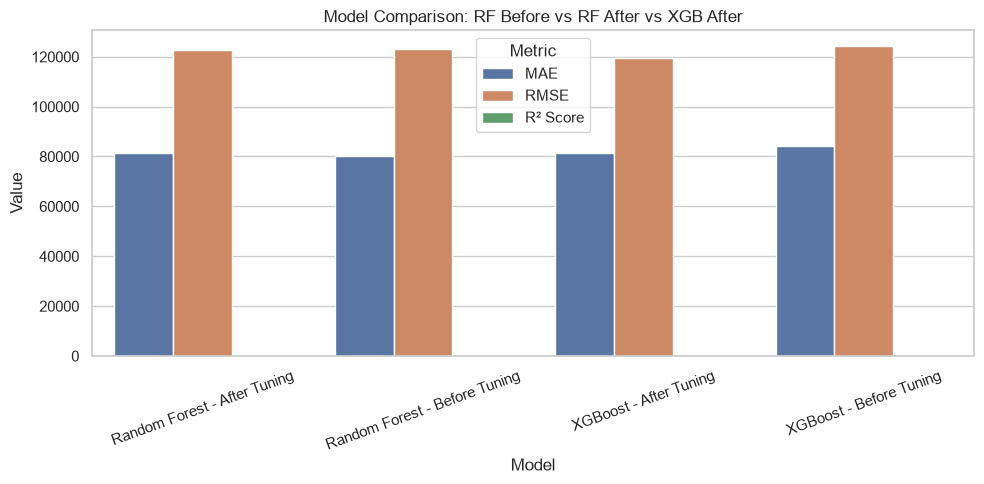

In [22]:
# Best rule: RMSE lowest, then R² highest, then MAE lowest
best = results_df.sort_values(
    by=["RMSE", "R² Score", "MAE"],
    ascending=[True, False, True]
).iloc[0]

print("Best Model Selected:")
print(f"  {best['Model']}")
print(f"  MAE   : {best['MAE']:.4f}")
print(f"  RMSE  : {best['RMSE']:.4f}")
print(f"  R²    : {best['R² Score']:.4f}")

plot_df = results_df.melt(id_vars="Model", value_vars=["MAE", "RMSE", "R² Score"],
                          var_name="Metric", value_name="Value")

plt.figure(figsize=(10,5))
sns.barplot(data=plot_df, x="Model", y="Value", hue="Metric")
plt.title("Model Comparison: RF Before vs RF After vs XGB After")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

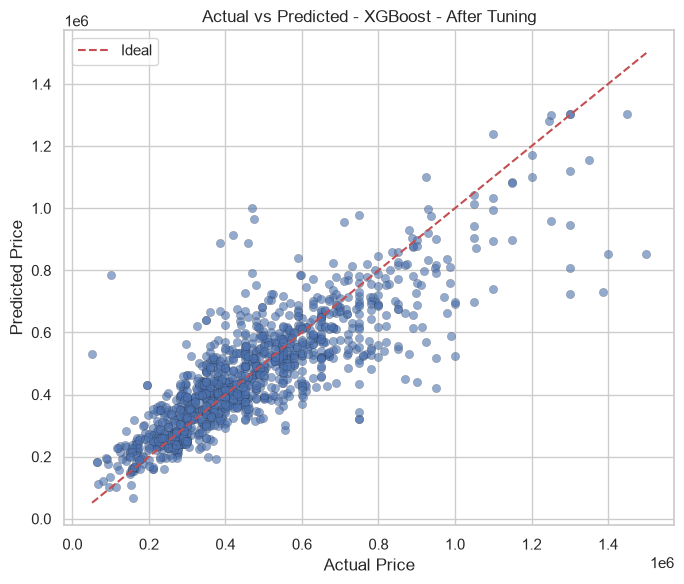

In [23]:
best_name = best["Model"]
best_pred = pred_store[best_name]

plt.figure(figsize=(7,6))
plt.scatter(y_test, best_pred, alpha=0.6, edgecolors="k", linewidth=0.2)
vmin = min(y_test.min(), best_pred.min())
vmax = max(y_test.max(), best_pred.max())
plt.plot([vmin, vmax], [vmin, vmax], "r--", label="Ideal")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted - {best_name}")
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
# Accuracy-style = 100 - MAPE
acc_rows = []

for name, y_pred in pred_store.items():
    safe_y = np.where(np.asarray(y_test) <= 0, 1.0, y_test)
    mape = np.mean(np.abs((np.asarray(y_test) - np.asarray(y_pred)) / safe_y)) * 100.0
    est_acc = max(0.0, min(100.0, 100.0 - mape))

    acc_rows.append({
        "Model": name,
        "MAPE (%)": mape,
        "Estimated Accuracy (%)": est_acc
    })

acc_df = pd.DataFrame(acc_rows).sort_values("Estimated Accuracy (%)", ascending=False).reset_index(drop=True)
display(acc_df.round(2))

,Model,MAPE (%),Estimated Accuracy (%)
0,Random Forest - Before Tuning,19.89,80.11
1,Random Forest - After Tuning,20.16,79.84
2,XGBoost - After Tuning,20.19,79.81
3,XGBoost - Before Tuning,20.72,79.28
